# 이상지질혈증 예측 - XGBoost Optuna
- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 데이터: `hn_all_preprocessed_v2.1.csv` (18~24년 통합)
- 모델: XGBoost + Optuna TPE Sampler
- Threshold: **0.45 고정**
- FE: 나이_구간 + 가족력_합계 + BMI_구간 (기본 적용)
- 목표: **Recall ≥ 0.80 유지하면서 F1 최대화**
- 검증: Stratified 5-Fold CV

In [21]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed_v2.1.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD = 0.45
N_TRIALS = 100

## 1. 데이터 로드

In [22]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (19765, 31)


## 2. ✏️ Feature Engineering 설정
> 순서 중요: `add_age_bin` → `add_family_sum` → 나머지

In [23]:
# df = add_age_bin(df)                    # ✅ 나이_구간
# df = add_family_sum(df,                 # ✅ 가족력_합계
#                     hypertension=True,
#                     diabetes=True,
#                     dyslipidemia=True)
# df = add_bmi_bin(df)                    # ✅ BMI_구간 (이상지질혈증 우선)
# df = add_alcohol_load(df)             # ❌ 음주_총부하
# df = add_exercise_total(df)           # ❌ 총운동일수
# df = add_body_features(df)            # ❌ 체형 복합 (이상지질혈증 특화)
# df = add_age_family_interaction(df,   # ❌ 나이×가족력
#                                 hypertension=False, diabetes=False)

print(f"\n피처 엔지니어링 완료 | shape: {df.shape}")


피처 엔지니어링 완료 | shape: (19765, 31)


## 3. 피처 / 타겟 분리

In [24]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}  |  정상: {neg}  |  이상지질혈증: {pos}")
print(f"불균형 비율: {ratio:.4f}:1")
print(f"사용 피처 수: {X.shape[1]}")

샘플 수: 19175  |  정상: 13732  |  이상지질혈증: 5443
불균형 비율: 2.5229:1
사용 피처 수: 28


## 4. Optuna Objective 정의

In [25]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 3.0),
        "scale_pos_weight": ratio,
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in cv.split(X, y):
        m = xgb.XGBClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])], verbose=False)
        proba = m.predict_proba(X.iloc[val_idx])[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        rec = recall_score(y.iloc[val_idx], pred)
        penalty = max(0, 0.8 - rec) * 2
        scores.append(f1_score(y.iloc[val_idx], pred) - penalty)
    return np.mean(scores)

## 5. Optuna 최적화 실행

In [26]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n최적 trial: {study.best_trial.number}")
print(f"최적 score: {study.best_value:.4f}")
print("\n[최적 파라미터]")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 0. Best value: 0.586824: 100%|██████████| 100/100 [07:20<00:00,  4.41s/it]


최적 trial: 0
최적 score: 0.5868

[최적 파라미터]
  n_estimators: 487
  learning_rate: 0.08927180304353628
  max_depth: 7
  min_child_weight: 6
  subsample: 0.6624074561769746
  colsample_bytree: 0.662397808134481
  gamma: 0.05808361216819946
  reg_alpha: 0.8661761457749352
  reg_lambda: 2.002787529358022


## 6. Optuna 최적화 과정 시각화

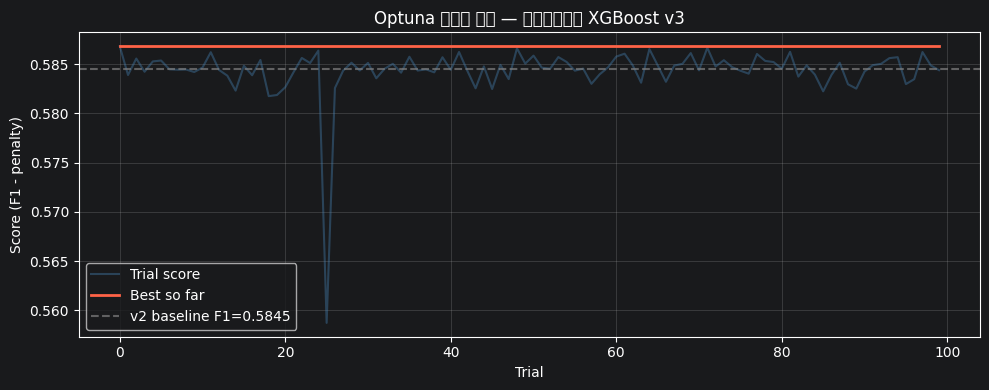

In [27]:
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)

plt.figure(figsize=(10, 4))
plt.plot(trial_values, alpha=0.4, color="steelblue", label="Trial score")
plt.plot(best_so_far, color="tomato", lw=2, label="Best so far")
plt.axhline(y=0.5845, color="gray", linestyle="--", alpha=0.7, label="v2 baseline F1=0.5845")
plt.xlabel("Trial")
plt.ylabel("Score (F1 - penalty)")
plt.title("Optuna 최적화 과정 — 이상지질혈증 XGBoost v3")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 최적 파라미터로 최종 학습 & 평가

In [28]:
best_params = study.best_params.copy()
best_params.update(
    {
        "scale_pos_weight": ratio,
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.7793 | Recall: 0.8548 | F1: 0.5782 | best_iter: 45
  Fold 2 | AUC: 0.8005 | Recall: 0.8686 | F1: 0.6027 | best_iter: 38
  Fold 3 | AUC: 0.7853 | Recall: 0.8384 | F1: 0.5786 | best_iter: 70
  Fold 4 | AUC: 0.7933 | Recall: 0.8356 | F1: 0.5890 | best_iter: 65
  Fold 5 | AUC: 0.7866 | Recall: 0.8567 | F1: 0.5857 | best_iter: 45
  평균   | AUC: 0.7890±0.0082 | Recall: 0.8508±0.0137 | F1: 0.5868±0.0100


## 8. OOF proba 저장 (.npy)

In [29]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_xgboost_v3_optuna.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_HL_xgboost_v3_optuna.npy
로드 확인: shape=(19175, 2), 일치=True


## 9. OOF 전체 성능 & v2 baseline 비교

In [30]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)
oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# v2 baseline (Optuna 파라미터 고정, FE 없음)
BASE = {"auc": 0.7855, "recall": 0.8414, "precision": 0.4477, "f1": 0.5845, "acc": 0.6604, "fp": 5649, "fn": 863}

print("=" * 58)
print(f"  {'지표':<12}  {'v2 baseline':>12}  {'v3 Optuna':>10}  변화")
print("=" * 58)
for label, base_v, cur_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = cur_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>12}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>12}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 58)
print("\n[분류 리포트]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "이상지질혈증(1)"]))

  지표             v2 baseline   v3 Optuna  변화
  AUC-ROC             0.7855      0.7888  ▲ 0.0033
  Recall              0.8414      0.8508  ▲ 0.0094
  Precision           0.4477      0.4478  ▲ 0.0001
  F1-score            0.5845      0.5868  ▲ 0.0023
  Accuracy            0.6604      0.6598  ▼ 0.0006
  FP                    5649        5711  ▲ 62
  FN                     863         812  ▼ 51

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.91      0.58      0.71     13732
   이상지질혈증(1)       0.45      0.85      0.59      5443

    accuracy                           0.66     19175
   macro avg       0.68      0.72      0.65     19175
weighted avg       0.78      0.66      0.68     19175



## 10. Confusion Matrix

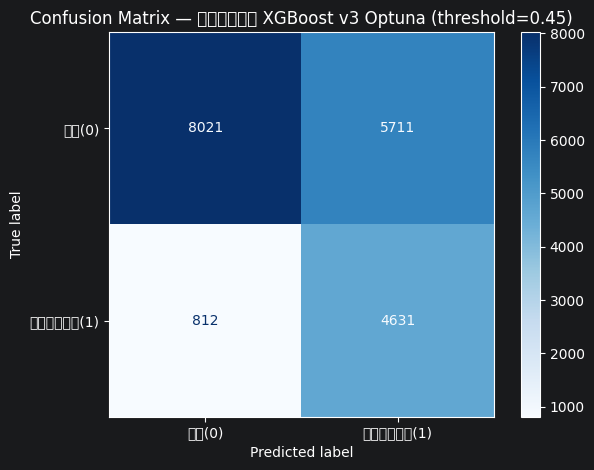

In [31]:
disp = ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "이상지질혈증(1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — 이상지질혈증 XGBoost v3 Optuna (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 11. Feature Importance (5-Fold 평균, gain)

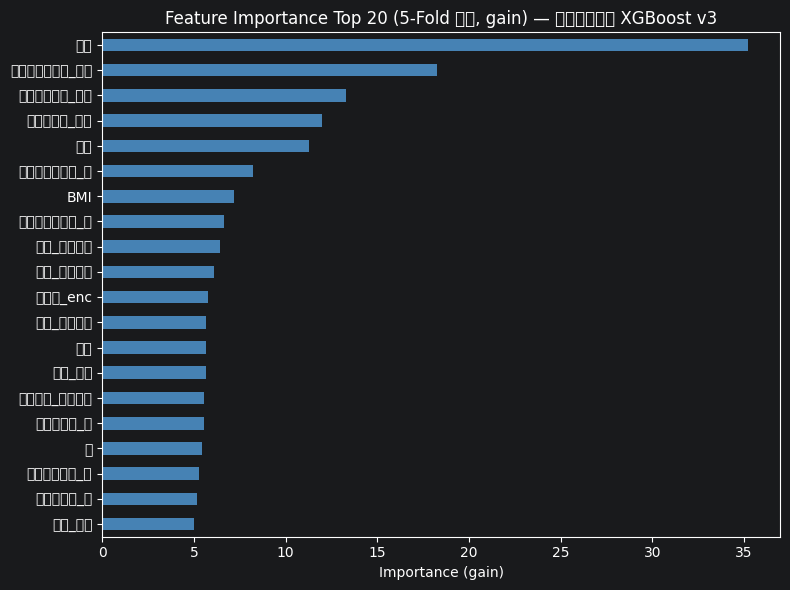

   1. 나이: 35.2
   2. 고지혈증가족력_형제: 18.3
   3. 고혈압가족력_형제: 13.3
   4. 당뇨가족력_형제: 12.0
   5. 성별: 11.3
   6. 고지혈증가족력_모: 8.2
   7. BMI: 7.2
   8. 고지혈증가족력_부: 6.6
   9. 직업_관리전문: 6.5
  10. 직업_주부학생: 6.1
  11. 음주량_enc: 5.8
  12. 직업_농림어업: 5.7
  13. 체중: 5.7
  14. 직업_사무: 5.7
  15. 과거음주_현재금주: 5.6
  16. 당뇨가족력_모: 5.6
  17. 키: 5.4
  18. 고혈압가족력_부: 5.3
  19. 당뇨가족력_부: 5.2
  20. 직업_무직: 5.0


In [32]:
fi_list = []
for fold, (tr_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y), 1
):
    m = xgb.XGBClassifier(**best_params)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])], verbose=False)
    gain = pd.Series(m.get_booster().get_score(importance_type="gain"))
    gain = gain.reindex(X.columns, fill_value=0)
    fi_list.append(gain)

fi = pd.DataFrame(fi_list).mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 20 (5-Fold 평균, gain) — 이상지질혈증 XGBoost v3")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()
for i, (feat, imp) in enumerate(fi.head(20).items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.1f}")

## 12. SHAP 분석 (OOF 전체 기준)

SHAP Fold 1 완료
SHAP Fold 2 완료
SHAP Fold 3 완료
SHAP Fold 4 완료
SHAP Fold 5 완료


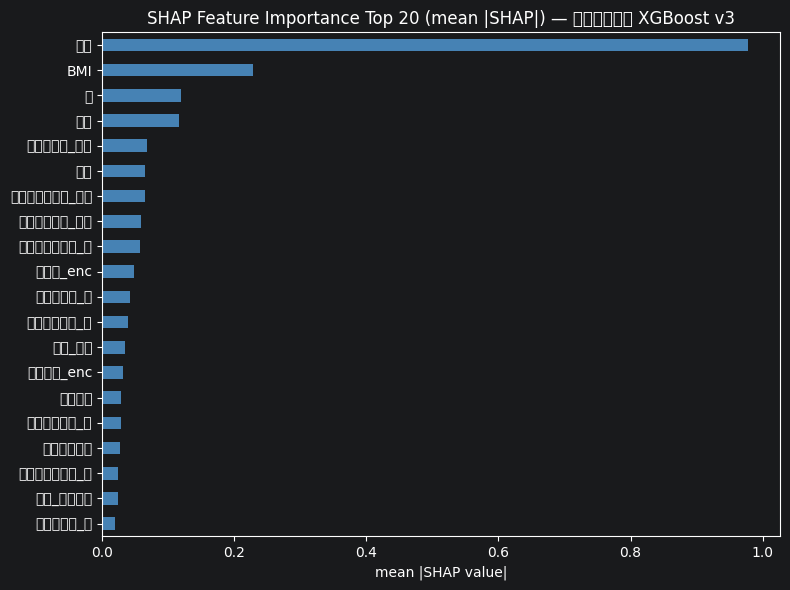

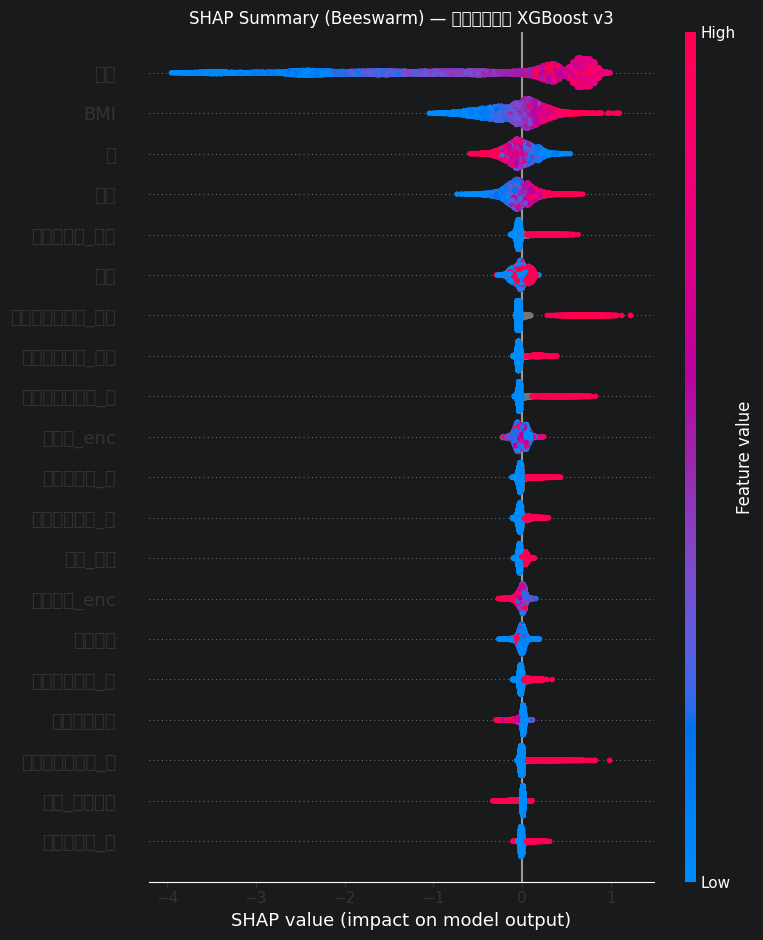

[SHAP Top 15]
   1. 나이: 0.9773
   2. BMI: 0.2281
   3. 키: 0.1193
   4. 체중: 0.1168
   5. 당뇨가족력_형제: 0.0675
   6. 성별: 0.0652
   7. 고지혈증가족력_형제: 0.0650
   8. 고혈압가족력_형제: 0.0591
   9. 고지혈증가족력_모: 0.0569
  10. 음주량_enc: 0.0488
  11. 당뇨가족력_모: 0.0422
  12. 고혈압가족력_모: 0.0397
  13. 직업_무직: 0.0348
  14. 음주빈도_enc: 0.0322
  15. 걷기일수: 0.0287


In [33]:
import shap

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
shap_values = np.zeros(X.shape)

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X, y), 1):
    m = xgb.XGBClassifier(**best_params)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])], verbose=False)
    explainer = shap.TreeExplainer(m)
    shap_values[val_idx] = explainer.shap_values(X.iloc[val_idx])
    print(f"SHAP Fold {fold} 완료")

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — 이상지질혈증 XGBoost v3")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 이상지질혈증 XGBoost v3", fontsize=12)
plt.tight_layout()
plt.show()

print("[SHAP Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 13. DB 로그 저장

In [34]:
sys.path.insert(0, BASE_DIR)
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))

base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE 적용: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="XGBoost",
    stage="v3_optuna",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "n_estimators": best_params["n_estimators"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "min_child_weight": best_params["min_child_weight"],
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],
        "gamma": best_params["gamma"],
        "reg_alpha": best_params["reg_alpha"],
        "reg_lambda": best_params["reg_lambda"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=mean_shap.head(15).to_dict(),
    note=f"v3 Optuna {N_TRIALS} trials. 데이터: hn_all_v2. {fe_note}",
)
print(f"저장 완료 → run_id: {run_id}  |  {fe_note}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=39 | 이상지질혈증 XGBoost (v3_optuna)
저장 완료 → run_id: 39  |  FE 없음
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
     39 2026-05-19 11:32:44     이상지질혈증    XGBoost      v3_optuna 0.788788 0.850818   0.447786  0.586760  0.659817
     38 2026-05-19 11:22:21        고혈압   CatBoost      v3_optuna 0.871250 0.839095   0.606238  0.703909  0.772653
     37 2026-05-19 11:20:39     이상지질혈증    XGBoost      v3_optuna 0.790924 0.884071   0.439251  0.586901  0.646728
     36 2026-05-19 11:16:22         당뇨   CatBoost      v3_optuna 0.817880 0.815546   0.427992  0.561378  0.699021
     35 2026-05-18 21:03:29     이상지질혈증    XGBoost         fe_exp 0.786431 0.841631   0.447801  0.584572  0.660443
     34 2026-05-18 20:59:32         당뇨   CatBoost         fe_exp 0.837461 0.802233   0.461519  0.585947  0.732238
     33 2026-05-18 20:57:17        고혈압   CatBoost         fe_exp 0.856212 0.832085   0.585538  0.687373  0.75623